## Import libraries

In [1]:
import SimpleITK as sitk # type: ignore
import os
import numpy as np # type: ignore
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
import shutil # type: ignore
import seaborn as sns # type: ignore
from skimage.metrics import peak_signal_noise_ratio as psnr # type: ignore
from skimage.metrics import structural_similarity as ssim # type: ignore
from sklearn.preprocessing import MinMaxScaler # type: ignore
from sklearn.preprocessing import StandardScaler # type: ignore
from sklearn.preprocessing import MaxAbsScaler # type: ignore
from sklearn.preprocessing import RobustScaler # type: ignore
from skimage.feature import graycomatrix, graycoprops
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, Input
from tensorflow.keras.layers import Lambda
from sklearn.model_selection import train_test_split
import random
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
from sklearn.metrics import classification_report

2025-05-06 20:52:04.330513: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746552124.355271  340223 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746552124.362937  340223 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-06 20:52:04.388969: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print("GPU Devices:", tf.config.list_physical_devices('GPU'))

Num GPUs Available: 1
GPU Devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth enabled for GPU")
    except RuntimeError as e:
        print("Error enabling memory growth:", e)

Memory growth enabled for GPU


## Load Datasets

In [4]:
df_adc = pd.read_csv("../Part3/df_adc.csv").set_index("Study Instance UID")
df_hbv = pd.read_csv("../Part3/df_hbv.csv").set_index("Study Instance_UID")
df_t2w = pd.read_csv("../Part3/df_t2w.csv").set_index("Study Instance UID")
# glcm_df = pd.read_csv("../Part3/glcm_df.csv")
df_adc_aug = pd.read_csv("df_adc_aug.csv").set_index("Study Instance UID")
df_hbv_aug = pd.read_csv("df_hbv_aug.csv").set_index("Study Instance_UID")
df_t2w_aug = pd.read_csv("df_t2w_aug.csv").set_index("Study Instance UID")

## CNN Models

### Padding the images

In [5]:
def change_size(df):
    for pic in df['path'].index:
        image = sitk.ReadImage(df['path'].loc[pic])

        new_size = [64, 64, image.GetDepth()]

        original_size = image.GetSize()
        original_spacing = image.GetSpacing()

        new_spacing = [
            original_spacing[0] * (original_size[0] / new_size[0]),
            original_spacing[1] * (original_size[1] / new_size[1]),
            original_spacing[2]
        ]

        resample = sitk.ResampleImageFilter()
        resample.SetOutputSpacing(new_spacing)
        resample.SetSize(new_size)
        resample.SetInterpolator(sitk.sitkLinear)
        resample.SetOutputDirection(image.GetDirection())
        resample.SetOutputOrigin(image.GetOrigin())
        resample.SetDefaultPixelValue(0)

        resampled_image = resample.Execute(image)
        os.makedirs("./Dataset_128", exist_ok=True)
        
        new_filename = df['path'].loc[pic].split('/')[-1]
        
        sitk.WriteImage(resampled_image, f"Dataset_128/{new_filename}")
        df.loc[pic, "path"] =  f"Dataset_128/{df['path'].loc[pic].split('/')[-1]}"

In [6]:
change_size(df_adc)
change_size(df_hbv)
change_size(df_t2w)

In [7]:
my_list = []
for i in df_hbv["path"]:
    image = sitk.ReadImage(i)
    my_list.append(image.GetDepth())

print(f"max: {max(my_list)}")
print(f"min: {min(my_list)}")

max: 33
min: 17


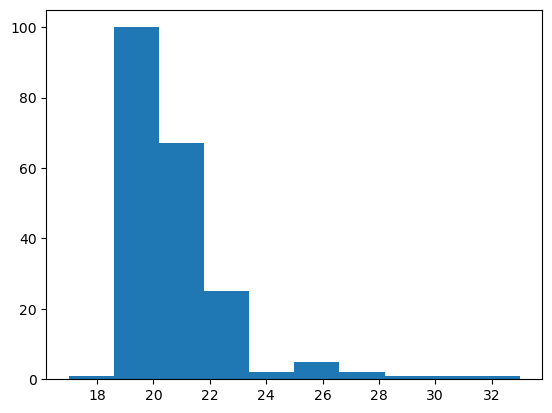

In [8]:
plt.hist(my_list)
plt.show()

In [9]:
def pad_image(image, target_depth = 33):
    current_depth = image.GetDepth()
    if current_depth != target_depth:
        befor_pad = (target_depth - current_depth) // 2 
        after_pad = (target_depth - current_depth - befor_pad)
        padded_image = sitk.ConstantPad(image, 
                                        padLowerBound=[0, 0, befor_pad],
                                        padUpperBound=[0, 0, after_pad],
                                        constant=0)
        return padded_image
    else:
        return image

def padded_images(df):
    os.makedirs("padded_images", exist_ok=True)
    for i, j in zip(df["path"], df.index):
        image = sitk.ReadImage(i)
        padded_image = pad_image(image)
        sitk.WriteImage(padded_image, f"padded_images/{i.split('/')[-1]}")
        df.loc[j, "path"] =  f"padded_images/{i.split('/')[-1]}"

In [10]:
padded_images(df_adc)
padded_images(df_t2w)
padded_images(df_hbv)

### train_test_split

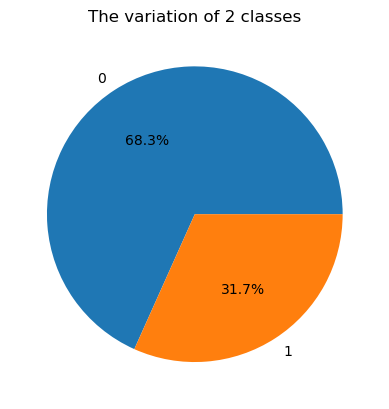

In [11]:
plt.pie(df_hbv["label"].value_counts(), labels=[0, 1], autopct="%1.1f%%")
plt.title("The variation of 2 classes")
plt.show()

In [12]:
def image_df(df, column):
    for i, j in enumerate(df[column]):
        image = sitk.ReadImage(j)
        image_arr = sitk.GetArrayFromImage(image)
        image_arr = np.expand_dims(image_arr, axis=0)
        if i == 0:
            x = image_arr
        else:
            x = np.concatenate((x, image_arr))
    return x

In [87]:
x_adc = image_df(df_adc, "path")
x_t2w = image_df(df_t2w, "path")
x_hbv = image_df(df_hbv, "path")

In [88]:
# x_adc = np.concatenate((x_adc, image_df(df_adc_aug, "rotated")))
# x_t2w = np.concatenate((x_t2w, image_df(df_t2w_aug, "rotated")))
# x_hbv = np.concatenate((x_hbv, image_df(df_hbv_aug, "rotated")))

In [89]:
print(f"x_adc shape: {x_adc.shape}\nx_t2w shape: {x_t2w.shape}\nx_hbv shape: {x_hbv.shape}")

x_adc shape: (205, 33, 64, 64)
x_t2w shape: (205, 33, 64, 64)
x_hbv shape: (205, 33, 64, 64)


In [114]:
y_label = df_t2w["label"]
y = y_label.to_numpy()
y.shape

(205,)

In [115]:
y = np.expand_dims(y, axis = 1)
y.shape

(205, 1)

In [116]:
one_hot_y = to_categorical(y, num_classes=2)
one_hot_y.shape

(205, 2)

In [117]:
X_train_adc, X_test_adc, y_train, y_test = train_test_split(x_adc, one_hot_y, train_size=0.7, random_state=42, shuffle=False)
X_train_hbv, X_test_hbv, y_train, y_test = train_test_split(x_hbv, one_hot_y, train_size=0.7, random_state=42, shuffle=False)
X_train_t2w, X_test_t2w, y_train, y_test = train_test_split(x_t2w, one_hot_y, train_size=0.7, random_state=42, shuffle=False)

In [118]:
y_train.shape

(143, 2)

### Build a CNN model

In [119]:
def cnn_model(input_shape=(33, 64, 64, 1)):
    inputs = Input(input_shape)
    x = layers.Conv3D(32, (3,3,3), activation="relu")(inputs)
    x = layers.MaxPooling3D((2,2,2))(x)
    x = layers.Conv3D(32, (3,3,3), activation="relu")(x)
    x = layers.MaxPooling3D((2,2,2))(x)
    x = layers.Conv3D(32, (3,3,3), activation="relu")(x)
    x = layers.MaxPooling3D((2,2,2))(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dropout(0.4)(x)
    return models.Model(inputs, outputs)

def cnn_model_voting(input_shape=(33, 64, 64, 1)):
    adc_branch = cnn_model(input_shape)
    hbv_branch = cnn_model(input_shape)
    t2w_branch = cnn_model(input_shape)

    adc_input = Input(input_shape, name="adc_input")
    hbv_input = Input(input_shape, name="hbv_input")
    t2w_input = Input(input_shape, name="t2w_input")

    adc_output = adc_branch(adc_input)
    hbv_output = hbv_branch(hbv_input)
    t2w_output = t2w_branch(t2w_input)

    fused = layers.Concatenate()([adc_output, hbv_output, t2w_output])

    output = layers.Dense(2, activation="softmax")(fused)
    
    model = models.Model(inputs=[adc_input, hbv_input, t2w_input], outputs=output)

    optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001)

    model.compile(optimizer=optimizer,
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model


In [120]:
model = cnn_model_voting()
model.summary()

Model: "functional_31"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ adc_input           │ (None, 33, 64,    │          0 │ -                 │
│ (InputLayer)        │ 64, 1)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hbv_input           │ (None, 33, 64,    │          0 │ -                 │
│ (InputLayer)        │ 64, 1)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ t2w_input           │ (None, 33, 64,    │          0 │ -                 │
│ (InputLayer)        │ 64, 1)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_28       │ (None, 128)       │    351,296 │ adc_input[0][0]   │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_29       │ (None, 128)       │    351,296 │ hbv_input[0][0]   │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_30       │ (None, 128)       │    351,296 │ t2w_input[0][0]   │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 384)       │          0 │ functional_28[0]… │
│ (Concatenate)       │                   │            │ functional_29[0]… │
│                     │                   │            │ functional_30[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 2)         │        770 │ concatenate_7[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,054,658 (4.02 MB)

 Trainable params: 1,054,658 (4.02 MB)

 Non-trainable params: 0 (0.00 B)

In [121]:
model.fit(
    {
        "adc_input": X_train_adc,
        "hbv_input": X_train_hbv,
        "t2w_input": X_train_t2w
    },
    y_train,
    batch_size=1,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.5495 - loss: 1.7378 - val_accuracy: 0.6552 - val_loss: 0.8979
Epoch 2/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.7224 - loss: 0.8790 - val_accuracy: 0.6552 - val_loss: 0.6354
Epoch 3/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6690 - loss: 0.7633 - val_accuracy: 0.6552 - val_loss: 0.6225
Epoch 4/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6305 - loss: 0.7379 - val_accuracy: 0.6552 - val_loss: 0.6540
Epoch 5/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6475 - loss: 0.7736 - val_accuracy: 0.6552 - val_loss: 1.8185
Epoch 6/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6711 - loss: 0.8173 - val_accuracy: 0.6552 - val_loss: 1.1323
Epoch 7/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.7391 - loss: 0.7750 - val_accuracy: 0.6552 - val_loss: 0.6538
Epoch 8/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.7213 - loss: 0.6477 - val_acc

In [122]:
model.evaluate([X_test_adc, X_test_hbv, X_test_t2w],  y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 756ms/step - accuracy: 0.6801 - loss: 0.6066


[0.6374382376670837, 0.6451612710952759]

In [123]:
y_train_pred = model.predict({
    "adc_input": X_train_adc,
    "hbv_input": X_train_hbv,
    "t2w_input": X_train_t2w
})
y_train_pred = np.argmax(y_train_pred, axis=1)

y_test_pred = model.predict({
    "adc_input": X_test_adc,
    "hbv_input": X_test_hbv,
    "t2w_input": X_test_t2w
})
y_test_pred = np.argmax(y_test_pred, axis=1)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 279ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 652ms/step


In [124]:
y_train = np.argmax(y_train, axis = 1)
y_test = np.argmax(y_test, axis = 1)

In [125]:
print("                              Train")
print()
print(classification_report(y_train, y_train_pred))

                              Train

              precision    recall  f1-score   support

           0       0.75      0.99      0.85       101
           1       0.89      0.19      0.31        42

    accuracy                           0.76       143
   macro avg       0.82      0.59      0.58       143
weighted avg       0.79      0.76      0.69       143



In [126]:
print("                              Test")
print()
print(classification_report(y_test, y_test_pred))

                              Test

              precision    recall  f1-score   support

           0       0.64      1.00      0.78        39
           1       1.00      0.04      0.08        23

    accuracy                           0.65        62
   macro avg       0.82      0.52      0.43        62
weighted avg       0.77      0.65      0.52        62



## Data Augmentation

In [11]:
def random_flip(image, name):
    flipper = sitk.FlipImageFilter()
    flip_axes = [bool(random.getrandbits(1)), bool(random.getrandbits(1)), bool(random.getrandbits(1))]
    flipper.SetFlipAxes(flip_axes)
    flipper.SetFlipAboutOrigin(True)
    flipped_image = flipper.Execute(image)
    os.makedirs("Augmented_images/fliped/", exist_ok=True)
    file_loc = f"Augmented_images/fliped/{name}"
    sitk.WriteImage(flipped_image, file_loc)
    return file_loc

In [12]:
def random_rotate(image, name):
    rotator = sitk.Euler3DTransform()
    center = image.TransformContinuousIndexToPhysicalPoint([
    s/2 for s in image.GetSize()
    ])
    rotator.SetCenter(center)
    angle_degrees = random.randint(0, 360)
    angle_radians = np.deg2rad(angle_degrees)
    rotator.SetRotation(angle_radians, angle_radians, 0.0)
    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(image) 
    resampler.SetInterpolator(sitk.sitkLinear)
    resampler.SetDefaultPixelValue(0)
    resampler.SetTransform(rotator)
    rotated_image = resampler.Execute(image)
    os.makedirs("Augmented_images/rotated/", exist_ok=True)
    file_loc = f"Augmented_images/rotated/{name}"
    sitk.WriteImage(rotated_image, file_loc)
    return file_loc

In [13]:
def random_transport(image, name):
    transform = sitk.TranslationTransform(3)
    offset = (random.uniform(-10, 10), random.uniform(-10, 10), random.uniform(-10, 10))
    transform.SetOffset(offset)
    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(image)
    resampler.SetInterpolator(sitk.sitkLinear)
    resampler.SetDefaultPixelValue(0)
    resampler.SetTransform(transform)
    translated_image = resampler.Execute(image)
    os.makedirs("Augmented_images/trasported/", exist_ok=True)
    file_loc = f"Augmented_images/trasported/{name}"
    sitk.WriteImage(translated_image, file_loc)
    return file_loc

In [14]:
def implement_aug(df):
    fliped_list = []
    rotate_list = []
    transport_list = []
    for i in df["path"]:
        image = sitk.ReadImage(i)
        file_loc = random_flip(image, i.split("/")[-1])
        fliped_list.append(file_loc)
        
        file_loc = random_rotate(image, i.split("/")[-1])
        rotate_list.append(file_loc)
    
        file_loc = random_transport(image, i.split("/")[-1])
        transport_list.append(file_loc)
    return pd.DataFrame(data=np.array([fliped_list, rotate_list, transport_list]).T,
                        columns=["fliped", "rotated", "transported"], index=df.index)

In [15]:
df_adc_aug = implement_aug(df_adc)
df_hbv_aug = implement_aug(df_hbv)
df_t2w_aug = implement_aug(df_t2w)

In [16]:
df_adc_aug.to_csv("df_adc_aug.csv")
df_hbv_aug.to_csv("df_hbv_aug.csv")
df_t2w_aug.to_csv("df_t2w_aug.csv")